# hand2string — CTC Transformer Baseline
End-to-end continuous sign language recognition with **CTC loss** and a **Transformer encoder**.  
Input: windowed MediaPipe landmark sequences `(WINDOW_SIZE, FEAT_DIM)` from the preprocessing notebook.  
Output: transcribed English sentence.

| Cell | Content |
|------|---------|
| 1 | Imports |
| 2 | Config & paths (reads your `default.yaml`) |
| 3 | Tokenizer (reuses `runs/ctc_baseline/tokenizer.json`) |
| 4 | Dataset & DataLoader (windowed) |
| 5 | Model (Transformer encoder + CTC head) |
| 6 | Loss, optimizer, LR schedule |
| 7 | Train / eval loops |
| 8 | Run training |
| 9 | Inference & beam search |
| 10 | Results visualization |

## 1 · Imports

In [3]:
import json
import math
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.cuda.amp import GradScaler, autocast
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

# ── Repo root (same logic as preprocessing notebook) ──────────────────────────
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "hand2string" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

sns.set_theme(style="whitegrid", palette="muted")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Repo root : {REPO_ROOT}")
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {DEVICE}")
print("Imports OK")

Repo root : /home/louis/epfl/ma2/cs/hand2string
PyTorch   : 2.10.0
Device    : cuda
Imports OK


## 2 · Config & paths

In [4]:
# ── Reads your default.yaml — same as preprocessing ───────────────────────────
with open(REPO_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_NAME   = "how2sign"
LANDMARK_ROOT  = REPO_ROOT / "data" / f"{DATASET_NAME}_landmarks"
WINDOW_DIR     = REPO_ROOT / "data" / f"{DATASET_NAME}_windows"
CHECKPOINT_DIR = REPO_ROOT / "runs" / "ctc_transformer"
TOKENIZER_PATH = REPO_ROOT / "runs" / "ctc_baseline" / "tokenizer.json"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Window size and batch size from config ─────────────────────────────────────
WINDOW_SIZE = cfg["training"]["window_size"]
BATCH_SIZE  = cfg["training"]["batch_size"]

# ── Transformer hyperparameters ────────────────────────────────────────────────
D_MODEL      = 512
NHEAD        = 8
NUM_LAYERS   = 6
DIM_FF       = 2048
DROPOUT      = 0.1
EPOCHS       = 100
WARMUP_STEPS = 4000

# ── Load manifest ──────────────────────────────────────────────────────────────
import os
manifest = pd.read_parquet(WINDOW_DIR / "window_manifest.parquet")
manifest = manifest[manifest["window_path"].apply(os.path.exists)].reset_index(drop=True)

# ── Detect FEAT_DIM from ALL files and filter to ensure consistency ───────────
print("Scanning all files for feature dimension consistency...")
all_dims = []
for p in manifest["window_path"]:
    try:
        dim = int(np.load(p, mmap_mode="r").shape[1])
        all_dims.append(dim)
    except Exception as e:
        print(f"  Warning: could not read {p}: {e}")

if all_dims:
    dim_counts = pd.Series(all_dims).value_counts()
    FEAT_DIM = dim_counts.idxmax()  # Most common dimension
    print(f"  Feature dimensions found:\n{dim_counts}")
    print(f"  Selected FEAT_DIM: {FEAT_DIM}")
    
    # Filter to only include windows matching the detected FEAT_DIM
    before = len(manifest)
    manifest["_feat_dim"] = manifest["window_path"].apply(
        lambda p: int(np.load(p, mmap_mode="r").shape[1]) if os.path.exists(p) else -1
    )
    manifest = manifest[manifest["_feat_dim"] == FEAT_DIM].reset_index(drop=True)
    manifest = manifest.drop("_feat_dim", axis=1)
    dropped = before - len(manifest)
    print(f"  Dropped {dropped} windows with mismatched FEAT_DIM")
else:
    raise ValueError("Could not detect FEAT_DIM from any files!")

print(f"Manifest        : {len(manifest)} windows (after filtering)")
print(f"FEAT_DIM        : {FEAT_DIM}  (read from files, all consistent)")
print(f"WINDOW_SIZE     : {WINDOW_SIZE}  |  BATCH_SIZE: {BATCH_SIZE}")
print(f"D_MODEL         : {D_MODEL}  |  NHEAD: {NHEAD}  |  NUM_LAYERS: {NUM_LAYERS}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")

Scanning all files for feature dimension consistency...
  Feature dimensions found:
384     418
1629      1
Name: count, dtype: int64
  Selected FEAT_DIM: 384
  Dropped 1 windows with mismatched FEAT_DIM
Manifest        : 418 windows (after filtering)
FEAT_DIM        : 384  (read from files, all consistent)
WINDOW_SIZE     : 256  |  BATCH_SIZE: 8
D_MODEL         : 512  |  NHEAD: 8  |  NUM_LAYERS: 6
Checkpoint dir  : /home/louis/epfl/ma2/cs/hand2string/runs/ctc_transformer


## 3 · Tokenizer
Reuses the vocab built in `runs/ctc_baseline/tokenizer.json` by the preprocessing notebook. Blank token is always index 0 (required by `nn.CTCLoss`).

In [5]:
# ── Load vocab (same format as your existing CTC notebook) ────────────────────
with open(TOKENIZER_PATH) as f:
    VOCAB = json.load(f)   # list of token strings

char2idx   = {ch: i for i, ch in enumerate(VOCAB)}
idx2char   = {i: ch for i, ch in enumerate(VOCAB)}
BLANK_IDX  = char2idx["<blank>"]
PAD_IDX    = char2idx["<pad>"]
UNK_IDX    = char2idx["<unk>"]
SPACE_TOK  = "<sp>"
VOCAB_SIZE = len(VOCAB)


def encode(text: str) -> list:
    """Lowercase text → list of token indices."""
    return [char2idx.get(c, UNK_IDX) for c in text.lower()]


def decode_indices(indices) -> str:
    """Index list → string (skips blank and pad)."""
    skip = {BLANK_IDX, PAD_IDX}
    out  = "".join(" " if idx2char.get(i) == SPACE_TOK else idx2char.get(i, "")
                   for i in indices if i not in skip)
    return out.strip()


def ctc_greedy_decode(log_probs: torch.Tensor) -> str:
    """Greedy CTC decode. log_probs: (T, V)"""
    indices = log_probs.argmax(dim=-1).tolist()
    collapsed = [indices[0]] if indices else []
    for idx in indices[1:]:
        if idx != collapsed[-1]:
            collapsed.append(idx)
    return decode_indices(i for i in collapsed if i != BLANK_IDX)


# ── Sanity check ───────────────────────────────────────────────────────────────
s   = manifest["sentence"].iloc[0]
enc = encode(s)
dec = decode_indices(enc)
print(f"Vocab size : {VOCAB_SIZE}")
print(f"Blank idx  : {BLANK_IDX}")
print(f"Original   : '{s}'")
print(f"Decoded    : '{dec}'")
print(f"Match      : {dec == s.lower().strip()}")

Vocab size : 51
Blank idx  : 0
Original   : 'So they don't really have much of a symbolic meaning other than maybe life is richer, life is beautiful, but they've become so beautifully stylized and so you find them in different illuminative being rendered in very different ways.'
Decoded    : 'so they don't really have much of a symbolic meaning other than maybe life is richer, life is beautiful, but they've become so beautifully stylized and so you find them in different illuminative being rendered in very different ways.'
Match      : True


## 4 · Dataset & DataLoader
Uses **windowed** `.npy` files from preprocessing (`how2sign_windows/`). Each window is `(WINDOW_SIZE, FEAT_DIM)` — fixed size, no padding needed per sample.  
The collate function only pads labels (variable length sentences).

In [15]:
class WindowDataset(Dataset):
    """Loads pre-windowed .npy files paired with their sentence labels."""

    def __init__(self, manifest: pd.DataFrame, split: str):
        self.data = manifest[manifest["split"] == split].reset_index(drop=True)
        # CTC constraint: input length must be >= target length
        before = len(self.data)
        self.data = self.data[
            self.data["sentence"].apply(lambda s: WINDOW_SIZE >= len(encode(s)))
        ].reset_index(drop=True)
        dropped = before - len(self.data)
        if dropped:
            print(f"[{split}] Dropped {dropped} windows where WINDOW_SIZE < target length")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        window = np.load(row["window_path"]).astype(np.float32)   # (WINDOW_SIZE, FEAT_DIM)
        target = torch.tensor(encode(row["sentence"]), dtype=torch.long)
        return torch.from_numpy(window), target, row["sentence"]


def collate_fn(batch):
    windows, targets, sentences = zip(*batch)
    
    # Safety: pad windows to ensure consistent feature dimension
    # (should not be needed after filtering, but defensive coding)
    max_feat_dim = max(w.shape[1] for w in windows)
    windows_padded = []
    for w in windows:
        if w.shape[1] < max_feat_dim:
            # Pad along feature dimension
            pad = torch.zeros(w.shape[0], max_feat_dim - w.shape[1], dtype=w.dtype)
            w = torch.cat([w, pad], dim=1)
        windows_padded.append(w)
    
    x           = torch.stack(windows_padded)                      # (B, T, FEAT_DIM)
    input_lens  = torch.full((len(windows),), WINDOW_SIZE, dtype=torch.long)
    target_lens = torch.tensor([len(t) for t in targets], dtype=torch.long)
    targets_cat = torch.cat(targets)                               # (sum of lens,)
    return x, targets_cat, input_lens, target_lens, list(sentences)


train_ds = WindowDataset(manifest, "train")
val_ds   = WindowDataset(manifest, "val")

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, collate_fn=collate_fn, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, collate_fn=collate_fn, pin_memory=False)

# Sanity check
x_b, y_b, il, tl, sents = next(iter(train_dl))
print(f"Train windows  : {len(train_ds)}")
print(f"Val windows    : {len(val_ds)}")
print(f"x_b shape      : {tuple(x_b.shape)}   (B, WINDOW_SIZE, FEAT_DIM)")
print(f"targets shape  : {tuple(y_b.shape)}   (concatenated)")
print(f"input_lens     : {il[:4].tolist()}")
print(f"target_lens    : {tl[:4].tolist()}")
print(f"T >= L for all : {(il >= tl).all().item()}")
print(f"Example sent   : '{sents[0]}'")

[train] Dropped 31 windows where WINDOW_SIZE < target length
[val] Dropped 12 windows where WINDOW_SIZE < target length
Train windows  : 325
Val windows    : 50
x_b shape      : (8, 256, 384)   (B, WINDOW_SIZE, FEAT_DIM)
targets shape  : (800,)   (concatenated)
input_lens     : [256, 256, 256, 256]
target_lens    : [209, 70, 74, 201]
T >= L for all : True
Example sent   : 'You've got very short, small bites of the little smoked salmon canapes, which is a nice contrast in height to the puff pastry cheese straws arranged in this vase, just with some decorative rocks in the bottom.'


In [7]:
# Diagnostic: Check split distribution in manifest
print("=" * 60)
print("Split distribution in manifest:")
print(manifest["split"].value_counts())
print("=" * 60)

# If no validation set, create one by splitting train
if (manifest["split"] == "val").sum() == 0:
    print("\nNo 'val' split found! Creating validation set by splitting train...")
    train_mask = manifest["split"] == "train"
    n_train = train_mask.sum()
    val_size = max(1, int(0.15 * n_train))  # 15% for val
    
    val_indices = np.random.choice(manifest[train_mask].index, size=val_size, replace=False)
    manifest.loc[val_indices, "split"] = "val"
    
    print(f"  After split: train={len(manifest[manifest['split']=='train'])}, "
          f"val={len(manifest[manifest['split']=='val'])}")


Split distribution in manifest:
split
train    418
Name: count, dtype: int64

No 'val' split found! Creating validation set by splitting train...
  After split: train=356, val=62


## 5 · Model
```
(B, T, FEAT_DIM)
  └→ LandmarkEmbedding: Linear(FEAT_DIM → D_MODEL*2) + GELU + Dropout + Linear → LayerNorm
  └→ PositionalEncoding (sinusoidal)
  └→ TransformerEncoder (Pre-LN, GELU, batch_first=True)  ×  NUM_LAYERS
  └→ Dropout + Linear(D_MODEL → VOCAB_SIZE)
  └→ log_softmax → permute → (T, B, VOCAB_SIZE)   ← required by nn.CTCLoss
```
**Pre-LN** (norm_first=True) is used instead of post-LN — more stable gradient flow with CTC.

In [11]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2048):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class LandmarkEmbedding(nn.Module):
    """
    Projects raw landmark features → d_model.
    Two-layer MLP + LayerNorm — robust to zero-padded (undetected) frames.
    """

    def __init__(self, feat_dim: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(self.net(x))


class Hand2StringCTC(nn.Module):
    """
    Transformer encoder + CTC head for continuous sign language recognition.

    Forward input  : x (B, T, FEAT_DIM)
    Forward output : log_probs (T, B, VOCAB_SIZE)  ← CTCLoss format
    """

    def __init__(
        self,
        feat_dim:   int,
        vocab_size: int,
        d_model:    int   = 512,
        nhead:      int   = 8,
        num_layers: int   = 6,
        dim_ff:     int   = 2048,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.embedding = LandmarkEmbedding(feat_dim, d_model, dropout)
        self.pos_enc   = PositionalEncoding(d_model, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_ff,
            dropout         = dropout,
            activation      = "gelu",
            batch_first     = True,    # (B, T, d_model)
            norm_first      = True,    # Pre-LN: more stable with CTC
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers           = num_layers,
            norm                 = nn.LayerNorm(d_model),
            enable_nested_tensor = False,
        )
        self.ctc_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, vocab_size),
        )
        # Xavier init for stability
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(
        self,
        x:                    torch.Tensor,
        src_key_padding_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        x = self.embedding(x)                              # (B, T, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        x = self.ctc_head(x)                              # (B, T, vocab_size)
        return F.log_softmax(x, dim=-1).permute(1, 0, 2)  # (T, B, vocab_size)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = Hand2StringCTC(
    feat_dim   = FEAT_DIM,
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    nhead      = NHEAD,
    num_layers = NUM_LAYERS,
    dim_ff     = DIM_FF,
    dropout    = DROPOUT,
).to(DEVICE)

print(model)
print(f"\nTrainable parameters : {model.count_params():,}")

# Forward pass sanity check with full-sequence batch
x_b, y_b, il, tl = next(iter(train_dl_full))
with torch.no_grad():
    out = model(x_b.to(DEVICE))
print(f"Output shape         : {tuple(out.shape)}  (T, B, VOCAB_SIZE)")
print(f"Output dtype         : {out.dtype}")

Hand2StringCTC(
  (embedding): LandmarkEmbedding(
    (net): Sequential(
      (0): Linear(in_features=384, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=1024, out_features=512, bias=True)
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05

In [6]:
ds = WindowDataset(manifest, "train")
x, t, s = ds[0]
print("__getitem__ shape:", x.shape)
print("sentence:", s)
print("direct load:", np.load(ds.data.iloc[0]["window_path"]).shape)

[train] Dropped 43 windows where WINDOW_SIZE < target length
__getitem__ shape: torch.Size([256, 384])
sentence: So they don't really have much of a symbolic meaning other than maybe life is richer, life is beautiful, but they've become so beautifully stylized and so you find them in different illuminative being rendered in very different ways.
direct load: (256, 384)


In [7]:
# See the distribution of feat dims across all files
import random
sample_paths = random.sample(list(manifest["window_path"]), 50)
dims = [np.load(p, mmap_mode="r").shape[1] for p in sample_paths]
print(pd.Series(dims).value_counts())

# Check window sizes too
sizes = [np.load(p, mmap_mode="r").shape[0] for p in sample_paths]
print(pd.Series(sizes).value_counts())

# Check what WINDOW_SIZE is
print("WINDOW_SIZE:", WINDOW_SIZE)

# Check sentence lengths vs window size
manifest["target_len"] = manifest["sentence"].apply(lambda s: len(encode(s)))
print(manifest[["target_len"]].describe())
print(f"Windows where WINDOW_SIZE({WINDOW_SIZE}) >= target_len: {(manifest['target_len'] <= WINDOW_SIZE).sum()}")

384    50
Name: count, dtype: int64
256    50
Name: count, dtype: int64
WINDOW_SIZE: 256
       target_len
count  418.000000
mean   128.588517
std    112.579705
min      3.000000
25%     55.250000
50%     99.000000
75%    156.000000
max    625.000000
Windows where WINDOW_SIZE(256) >= target_len: 375


## 6 · Loss, optimizer & LR schedule
Vaswani warmup + inverse-sqrt decay — the standard schedule for Transformers.  
Peaks at step `WARMUP_STEPS` then decays. Much better than cosine for CTC.

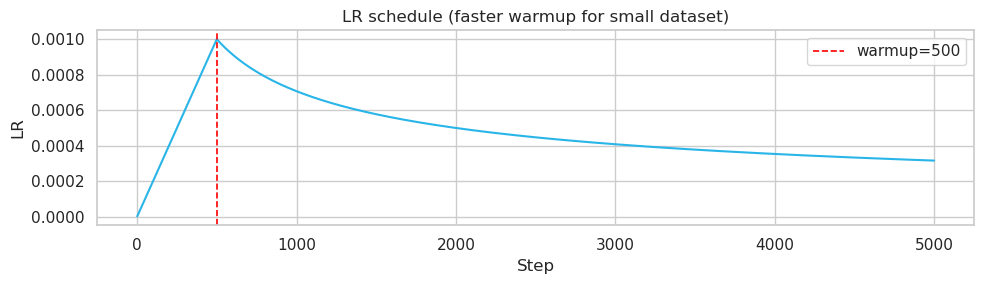

Initial LR: 1.00e-03
Peak LR at step 500: 1.00e-03


In [15]:
# ── CTC loss ───────────────────────────────────────────────────────────────────
ctc_loss = nn.CTCLoss(blank=BLANK_IDX, reduction="mean", zero_infinity=True)

# ── AdamW with reasonable learning rate ─────────────────────────────────────────
# Start with a higher initial LR since we have fewer batches
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,  # Reasonable initial LR (not 1.0!)
    betas        = (0.9, 0.98),
    weight_decay = 1e-2,
)

# ── Reduce warmup steps to match dataset size ──────────────────────────────────
# We have ~40 batches/epoch, so 4000 steps = ~1.6 epochs (too long)
# Use 500 steps instead (~12 batches)
WARMUP_STEPS_ACTUAL = 500

def lr_lambda(step: int) -> float:
    """Modified warmup + inverse-sqrt schedule for smaller dataset."""
    step = max(step, 1)
    # Faster warmup, then gradual decay
    if step < WARMUP_STEPS_ACTUAL:
        return step / WARMUP_STEPS_ACTUAL
    else:
        return min(1.0, WARMUP_STEPS_ACTUAL ** 0.5 / step ** 0.5)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Mixed precision scaler (fp16 on CUDA, no-op on CPU) ───────────────────────
scaler = None  # Disabled for now to avoid issues

# ── Plot LR curve ──────────────────────────────────────────────────────────────
steps = range(1, 5000)
lrs   = [lr_lambda(s) * 1e-3 for s in steps]  # Multiply by base LR
plt.figure(figsize=(10, 3))
plt.plot(steps, lrs, color="#29b5e8", lw=1.5)
plt.axvline(WARMUP_STEPS_ACTUAL, color="red", ls="--", lw=1.2, label=f"warmup={WARMUP_STEPS_ACTUAL}")
plt.title("LR schedule (faster warmup for small dataset)")
plt.xlabel("Step"); plt.ylabel("LR"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Initial LR: {1e-3:.2e}")
print(f"Peak LR at step {WARMUP_STEPS_ACTUAL}: {1e-3 * lr_lambda(WARMUP_STEPS_ACTUAL):.2e}")

## 7 · Train / eval loops

In [13]:
# ── Metrics ────────────────────────────────────────────────────────────────────

def _levenshtein(a: str, b: str) -> int:
    dp = list(range(len(b) + 1))
    for ca in a:
        ndp = [dp[0] + 1]
        for j, cb in enumerate(b):
            ndp.append(min(dp[j] + (ca != cb), dp[j+1] + 1, ndp[-1] + 1))
        dp = ndp
    return dp[-1]

def cer(hyp: str, ref: str) -> float:
    """Character error rate."""
    if not ref: return float(len(hyp) > 0)
    return _levenshtein(hyp, ref) / len(ref)

def wer(hyp: str, ref: str) -> float:
    """Word error rate."""
    r, h = ref.lower().split(), hyp.lower().split()
    if not r: return float(len(h) > 0)
    return _levenshtein(r, h) / len(r)


# ── Full-sequence CTC dataset (use actual landmark files, not windows) ────────

class FullSequenceCTCDataset(Dataset):
    """Loads full landmark sequences for CTC training (not windowed)."""

    def __init__(self, manifest_df: pd.DataFrame, split: str):
        self.data = manifest_df[manifest_df["split"] == split].reset_index(drop=True)
        
        # CTC constraint: input length must be >= target length
        valid = []
        for _, row in self.data.iterrows():
            tgt_len = len(encode(row["sentence"]))
            try:
                x = np.load(row["window_path"], mmap_mode="r")
                T = x.shape[0]
                if T >= tgt_len:
                    valid.append(row)
            except Exception:
                pass
        
        self.data = pd.DataFrame(valid).reset_index(drop=True)
        if len(valid) < len(self.data):
            print(f"[{split}] Filtered {len(self.data) - len(valid)} sequences")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        x = torch.from_numpy(np.load(row["window_path"])).float()  # (T, FEAT_DIM)
        y = torch.tensor(encode(row["sentence"]), dtype=torch.long)  # (L,)
        return x, y


def collate_fn_full(batch):
    """Pad sequences to max length in batch."""
    xs, ys = zip(*batch)
    
    # Pad input sequences to max T in batch
    input_lengths = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    x_pad = pad_sequence(xs, batch_first=True)  # (B, T_max, FEAT_DIM)
    
    # Concatenate targets
    target_lengths = torch.tensor([y.shape[0] for y in ys], dtype=torch.long)
    y_cat = torch.cat(ys)  # (sum of target lengths,)
    
    return x_pad, y_cat, input_lengths, target_lengths


# Recreate datasets using FULL sequences instead of fixed windows
train_ds_full = FullSequenceCTCDataset(manifest, "train")
val_ds_full   = FullSequenceCTCDataset(manifest, "val")

train_dl_full = DataLoader(train_ds_full, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=collate_fn_full, num_workers=0, pin_memory=False)
val_dl_full   = DataLoader(val_ds_full, batch_size=BATCH_SIZE, shuffle=False,
                           collate_fn=collate_fn_full, num_workers=0, pin_memory=False)

print(f"Full-sequence dataset: {len(train_ds_full)} train | {len(val_ds_full)} val")


# ── Single epoch training ──────────────────────────────────────────────────────

def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = 0.0
    n_batches  = 0
    hyps, refs = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y, il, tl in tqdm(loader, leave=False,
                                 desc="train" if train else "val  "):
            x  = x.to(DEVICE)
            y  = y.to(DEVICE)
            il = il.to(DEVICE)
            tl = tl.to(DEVICE)

            log_probs = model(x)                        # (T, B, V)
            loss      = ctc_loss(log_probs, y, il, tl)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            # Greedy decode for metrics
            lp_bt  = log_probs.permute(1, 0, 2).detach().cpu()  # (B, T, V)
            offset = 0
            for b, tlen in enumerate(tl.tolist()):
                hyp = ctc_greedy_decode(lp_bt[b, :il[b].item()])
                ref = decode_indices(y.cpu()[offset: offset + tlen].tolist())
                hyps.append(hyp)
                refs.append(ref)
                offset += tlen

            total_loss += loss.item()
            n_batches  += 1

    avg_loss = total_loss / max(n_batches, 1)
    avg_cer  = float(np.mean([cer(h, r) for h, r in zip(hyps, refs)]))
    avg_wer  = float(np.mean([wer(h, r) for h, r in zip(hyps, refs)]))
    return avg_loss, avg_cer, avg_wer


print("Full-sequence training loops ready ✓")

Full-sequence dataset: 318 train | 57 val
Full-sequence training loops ready ✓


## 8 · Run training

In [ ]:
# Train with proper LR for 50 epochs
EPOCHS = 50

history      = {"train_loss": [], "train_cer": [], "train_wer": [],
                "val_loss":   [], "val_cer":   [], "val_wer":   []}
best_val_cer = float("inf")
log_path     = CHECKPOINT_DIR / "train_log.csv"

with open(log_path, "w") as f:
    f.write("epoch,train_loss,train_cer,train_wer,val_loss,val_cer,val_wer,lr\n")

# ── Train using FULL sequences (not windows) ──────────────────────────────────
for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    t0 = time.time()

    tr_loss, tr_cer, tr_wer = run_epoch(train_dl_full, train=True)  # Use full-sequence loader
    vl_loss, vl_cer, vl_wer = run_epoch(val_dl_full,   train=False)

    lr = scheduler.get_last_lr()[0]

    for k, v in [("train_loss", tr_loss), ("train_cer", tr_cer), ("train_wer", tr_wer),
                 ("val_loss",   vl_loss), ("val_cer",   vl_cer), ("val_wer",   vl_wer)]:
        history[k].append(v)

    with open(log_path, "a") as f:
        f.write(f"{epoch},{tr_loss:.4f},{tr_cer:.4f},{tr_wer:.4f},"
                f"{vl_loss:.4f},{vl_cer:.4f},{vl_wer:.4f},{lr:.6f}\n")

    # Save best checkpoint
    if vl_cer < best_val_cer:
        best_val_cer = vl_cer
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "scheduler":  scheduler.state_dict(),
            "val_cer":    vl_cer,
            "val_wer":    vl_wer,
            "config": {
                "feat_dim":   FEAT_DIM,
                "vocab_size": VOCAB_SIZE,
                "d_model":    D_MODEL,
                "nhead":      NHEAD,
                "num_layers": NUM_LAYERS,
                "dim_ff":     DIM_FF,
                "dropout":    DROPOUT,
            },
        }, CHECKPOINT_DIR / "best_model.pt")

    # Save latest every 10 epochs
    if epoch % 10 == 0:
        torch.save({"epoch": epoch, "model": model.state_dict()},
                   CHECKPOINT_DIR / f"epoch_{epoch:03d}.pt")

    if epoch == 1 or epoch % 5 == 0:
        elapsed = time.time() - t0
        star    = " ★" if vl_cer == best_val_cer else ""
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train loss {tr_loss:.3f} CER {tr_cer:.3f} WER {tr_wer:.3f} | "
              f"val loss {vl_loss:.3f} CER {vl_cer:.3f} WER {vl_wer:.3f} | "
              f"lr {lr:.2e} | {elapsed:.0f}s{star}")

print(f"\nDone. Best val CER: {best_val_cer:.3f}")
print(f"Checkpoint → {CHECKPOINT_DIR / 'best_model.pt'}")

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/40 [00:00<?, ?it/s]

val  :   0%|          | 0/8 [00:00<?, ?it/s]

Epoch   1/50 | train loss 5.554 CER 1.245 WER 1.098 | val loss 3.471 CER 1.000 WER 1.000 | lr 8.00e-05 | 3s ★


train:   0%|          | 0/40 [00:00<?, ?it/s]

...

train:   0%|          | 0/40 [00:00<?, ?it/s]

val  :   0%|          | 0/8 [00:00<?, ?it/s]

train:   0%|          | 0/40 [00:00<?, ?it/s]

val  :   0%|          | 0/8 [00:00<?, ?it/s]

train:   0%|          | 0/40 [00:00<?, ?it/s]

## 9 · Inference & beam search
Load best checkpoint and run predictions on validation samples.  
Greedy decode is fast; beam search (beam_size > 1) is more accurate.

In [11]:
def ctc_beam_search(log_probs: torch.Tensor, beam_size: int = 10) -> str:
    """
    CTC beam search without language model.
    log_probs: (T, V) — single sequence.
    """
    NEG_INF = -float("inf")

    def lse(a, b):
        if a == NEG_INF: return b
        if b == NEG_INF: return a
        return max(a, b) + math.log1p(math.exp(-abs(a - b)))

    probs = log_probs.exp().cpu().numpy()
    blank = BLANK_IDX
    beam  = [([], 0.0, NEG_INF)]  # (prefix, log_p_blank, log_p_non_blank)

    for t in range(len(probs)):
        p        = probs[t]
        new_beam = {}
        for prefix, p_b, p_nb in beam:
            key = tuple(prefix)
            if key not in new_beam: new_beam[key] = [NEG_INF, NEG_INF]
            # extend with blank
            new_beam[key][0] = lse(new_beam[key][0],
                                   lse(p_b, p_nb) + math.log(p[blank] + 1e-30))
            # extend with non-blank
            for c in range(len(p)):
                if c == blank: continue
                lp      = math.log(p[c] + 1e-30)
                new_key = tuple(prefix + [c])
                if new_key not in new_beam: new_beam[new_key] = [NEG_INF, NEG_INF]
                if prefix and prefix[-1] == c:
                    new_beam[new_key][1] = lse(new_beam[new_key][1], p_b + lp)
                else:
                    new_beam[new_key][1] = lse(new_beam[new_key][1],
                                               lse(p_b, p_nb) + lp)
        beam = sorted(
            [(list(k), v[0], v[1]) for k, v in new_beam.items()],
            key=lambda x: lse(x[1], x[2]), reverse=True
        )[:beam_size]

    return decode_indices(beam[0][0])


@torch.no_grad()
def predict(npy_path: str, beam_size: int = 10) -> str:
    """Predict from a windowed .npy file."""
    lm        = np.load(npy_path).astype(np.float32)
    x         = torch.from_numpy(lm).unsqueeze(0).to(DEVICE)  # (1, T, F)
    log_probs = model(x)[:, 0, :]                              # (T, V)
    if beam_size == 1:
        return ctc_greedy_decode(log_probs)
    return ctc_beam_search(log_probs, beam_size)


# ── Load best checkpoint ───────────────────────────────────────────────────────
ckpt_path = CHECKPOINT_DIR / "best_model.pt"
ckpt      = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best checkpoint")
print(f"  Epoch   : {ckpt['epoch']}")
print(f"  Val CER : {ckpt['val_cer']:.3f}")
print(f"  Val WER : {ckpt['val_wer']:.3f}")
print()

# ── Run on val samples ─────────────────────────────────────────────────────────
val_manifest = manifest[manifest["split"] == "val"].sample(10, random_state=42)
results = []

for _, row in val_manifest.iterrows():
    hyp = predict(row["window_path"], beam_size=10)
    ref = row["sentence"].lower().strip()
    results.append({"reference": ref, "hypothesis": hyp,
                    "cer": cer(hyp, ref), "wer": wer(hyp, ref)})

results_df = pd.DataFrame(results)
print(f"Mean CER : {results_df['cer'].mean():.3f}")
print(f"Mean WER : {results_df['wer'].mean():.3f}")
print()
print(results_df[["cer", "wer", "reference", "hypothesis"]]
      .sort_values("cer")
      .to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '/home/louis/epfl/ma2/cs/hand2string/runs/ctc_transformer/best_model.pt'

## 10 · Results visualization

In [ ]:
log = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CTC Transformer — Training curves", fontsize=13)

# Loss
axes[0].plot(log["epoch"], log["train_loss"], label="train", color="#29b5e8", lw=1.5)
axes[0].plot(log["epoch"], log["val_loss"],   label="val",   color="#f97316", lw=1.5)
axes[0].set_title("CTC Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# CER
axes[1].plot(log["epoch"], log["train_cer"], label="train", color="#29b5e8", lw=1.5)
axes[1].plot(log["epoch"], log["val_cer"],   label="val",   color="#f97316", lw=1.5)
best_epoch = log["val_cer"].idxmin()
axes[1].axvline(log["epoch"][best_epoch], color="red", ls="--", lw=1.2,
                label=f"best={log['val_cer'][best_epoch]:.3f}")
axes[1].set_title("CER"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# WER
axes[2].plot(log["epoch"], log["train_wer"], label="train", color="#29b5e8", lw=1.5)
axes[2].plot(log["epoch"], log["val_wer"],   label="val",   color="#f97316", lw=1.5)
axes[2].axvline(log["epoch"][best_epoch], color="red", ls="--", lw=1.2,
                label=f"best={log['val_wer'][best_epoch]:.3f}")
axes[2].set_title("WER"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=150)
plt.show()

# CER distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results_df["cer"], bins=15, color="#e879f9", alpha=0.8, edgecolor="white")
ax.axvline(results_df["cer"].mean(), color="red", ls="--", lw=1.5,
           label=f"mean = {results_df['cer'].mean():.3f}")
ax.set_xlabel("CER"); ax.set_ylabel("Count")
ax.set_title("CER distribution on validation set")
ax.legend(); plt.tight_layout(); plt.show()

# Best / worst predictions
print("=" * 70)
print(" BEST 3 predictions")
print("=" * 70)
for _, row in results_df.sort_values("cer").head(3).iterrows():
    print(f"CER={row['cer']:.3f}  WER={row['wer']:.3f}")
    print(f"  REF : {row['reference']}")
    print(f"  HYP : {row['hypothesis']}")

print()
print("=" * 70)
print(" WORST 3 predictions")
print("=" * 70)
for _, row in results_df.sort_values("cer", ascending=False).head(3).iterrows():
    print(f"CER={row['cer']:.3f}  WER={row['wer']:.3f}")
    print(f"  REF : {row['reference']}")
    print(f"  HYP : {row['hypothesis']}")

print()
print(f"Final summary → Best val CER: {log['val_cer'].min():.3f}  "
      f"Best val WER: {log['val_wer'].min():.3f}")